# Milestone 5 — M5D: particle source delta → camera

Milestone 5D carries the validated M5C particle-induced source delta through the
existing M4 diffusion and camera pipeline.

Central question:

> Does the particle-induced source perturbation propagate through diffusion and
> appear as a camera-space signal?

Plan: [`plans/milestone_05/05_particle_plan.md`](../../plans/milestone_05/05_particle_plan.md).  
Guidelines: [`docs/milestone_05_particle_guidelines.md`](../../docs/milestone_05_particle_guidelines.md).

Spine:

1. deterministic challenge scene,
2. validated M5C source delta (via `run_m5d_simulation`),
3. clean / particle / delta diffusion fields,
4. camera response,
5. source → fluence → camera deltas side by side.

Main case: one **interior mixed** particle. Near the end: two-particle case with
a near-surface high-absorption inclusion, hybrid imaging, and shorter Robin length.

`run_m5d_simulation` is an inspectable reference — not a production M6 generator.


In [1]:
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not find repository root (pyproject.toml).")
    ROOT = ROOT.parent

!pip install --quiet --no-cache-dir "{ROOT}[fem,dev]" -c "{ROOT}/requirements.txt"

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from gummybear.geometry import load_stl
from gummybear.optics import OpticalMaterialConfig, PointLightConfig, generate_diffusion_mesh
from gummybear.particles import ParticleSet, ParticleSphere
from gummybear.paths import display_path
from gummybear.rays import PinholeCameraConfig
from gummybear_validation.helpers import assert_live_netgen_mesh
from gummybear_validation.milestone_05 import M5DSimulationConfig, run_m5d_simulation
from gummybear_validation.plotting import plot_m5d_final_images, plot_m5d_propagation


## 2. Deterministic challenge scene (single particle)

One visible mixed particle near the mesh centroid. The question is whether the
validated M5C source delta propagates consistently through diffusion and camera
sampling — not whether the scene is generally realistic.


In [3]:
STL_PATH = ROOT / "cad" / "proto_bear.stl"

TARGET_ELEMENTS = 1000
N_SOURCE_RAYS = 1000
RAY_SEED = 0
CAMERA_RESOLUTION = 96

EXTRAPOLATION_LENGTH = 5.0
EXITANCE_SCALE = 10.0
ALPHA = 0.0

material = OpticalMaterialConfig(
    n_refractive=1.33,
    mu_scatter=0.03,
    mu_absorption=0.0,
    g=0.0,
)

surface_mesh = load_stl(STL_PATH)
diff_mesh = generate_diffusion_mesh(STL_PATH, target_elements=TARGET_ELEMENTS)
assert_live_netgen_mesh(diff_mesh)

center = diff_mesh.bounds.mean(axis=0)

particles = ParticleSet.from_particles(
    [
        ParticleSphere(
            center=center,
            radius=3.0,
            mu_abs=0.5,
            mu_scat=0.5,
            particle_id="p000_m5d_challenge",
        )
    ]
)

light = PointLightConfig(position=(0.0, 20.0, 10.0), intensity=100.0)

camera = PinholeCameraConfig(
    camera_position=(0.0, -50.0, 0.0),
    look_at=tuple(center),
    up=(0.0, 0.0, 1.0),
    fov_deg=35.0,
    resolution=CAMERA_RESOLUTION,
)

config = M5DSimulationConfig(
    stl_path=STL_PATH,
    surface_mesh=surface_mesh,
    diff_mesh=diff_mesh,
    material=material,
    light=light,
    camera=camera,
    particles=particles,
    target_elements=TARGET_ELEMENTS,
    n_source_rays=N_SOURCE_RAYS,
    ray_seed=RAY_SEED,
    extrapolation_length=EXTRAPOLATION_LENGTH,
    exitance_scale=EXITANCE_SCALE,
    alpha=ALPHA,
    compute_direct=False,
)

print(f"STL={display_path(STL_PATH)}")
print("alpha / compute_direct:", config.alpha, config.compute_direct)


STL=cad/proto_bear.stl
alpha / compute_direct: 0.0 False


## 3. Run simulation


In [4]:
result = run_m5d_simulation(config)

print("M5D simulation prepared:")
print("  source rays       =", result.diagnostics.n_source_rays)
print("  refracted rays    =", result.diagnostics.n_refracted)
print("  closed segments   =", result.diagnostics.n_segments)
print("  affected paths    =", result.diagnostics.n_affected_paths)
print("  affected fraction =", result.diagnostics.affected_fraction)
print("  linearity error   =", result.diagnostics.linearity_error)
print("  source assignment =", result.diagnostics.source_assignment)
print("  source distribution =", result.diagnostics.source_distribution)


M5D simulation prepared:
  source rays       = 1000
  refracted rays    = 823
  closed segments   = 823
  affected paths    = 170
  affected fraction = 0.2065613608748481
  linearity error   = 2.266951906821778e-15
  source assignment = attenuated_chord
  source distribution = exact_ray_tet_beer_lambert


# Transfer of the particle delta signal to camera space

Volumetric delta signal (enhanced and decreased scattering deposition) is
transferred to surface / camera via diffusion.


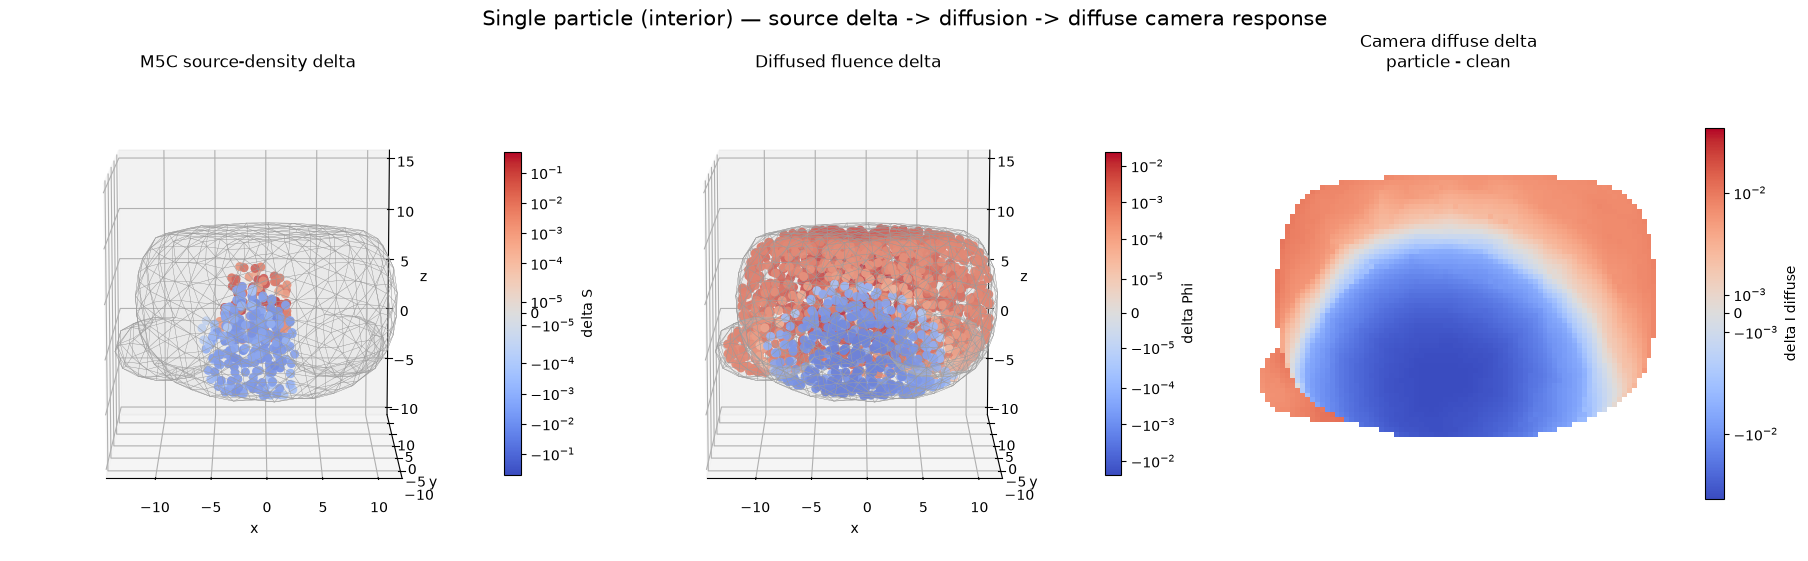

In [5]:
plot_m5d_propagation(
    result,
    "Single particle (interior) — source delta -> diffusion -> diffuse camera response",
)


# Visible trace of the particle presence in the terminal camera image

The particle is not directly imaged. It modifies illumination transport, which
alters the source used by diffusion; the change appears as a smooth diffuse
perturbation in camera space.

Intended M5D contract:

```text
particle → source perturbation → fluence perturbation → camera perturbation
```

No remesh / operator change — only the transport-derived source field changes.


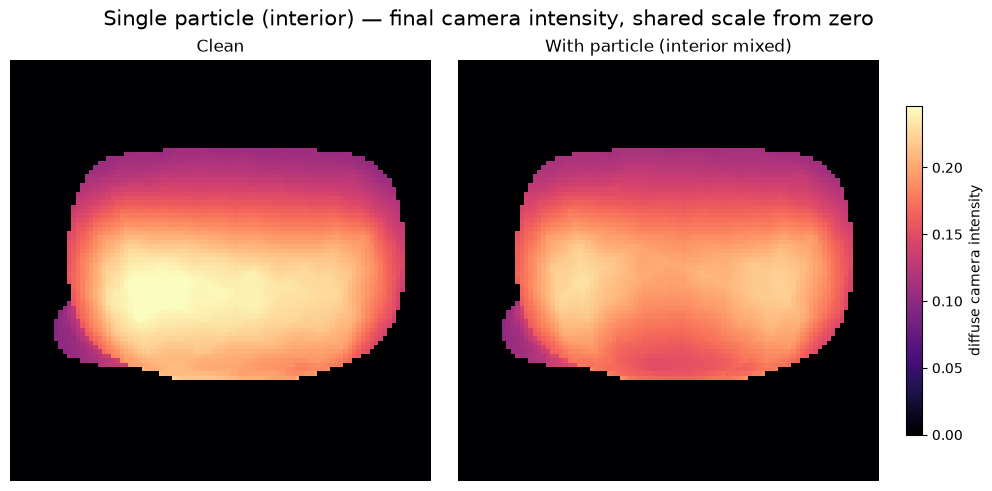

Final camera intensity comparison:
  image type           = diffuse camera intensity
  clean sum            = 686.8013186132257
  particle sum         = 646.3251070994365
  particle - clean sum = -40.476211513789075


In [6]:
plot_m5d_final_images(
    result,
    "Single particle (interior) — final camera intensity, shared scale from zero",
    "With particle (interior mixed)",
)


# 6. Two-particle near-surface high-absorption figure case

Two non-overlapping particles:

1. interior mixed particle,
2. high-`mu_a` particle near the camera-facing surface.

Direct transport and hybrid composition enabled
(`I_total = alpha * I_direct + I_diffuse`). Robin extrapolation length reduced
by 5× to sharpen visible shadows.


In [7]:
camera_pos = np.asarray(camera.camera_position, dtype=float)
toward_camera = camera_pos - center
toward_camera = toward_camera / np.linalg.norm(toward_camera)

interior_particle = ParticleSphere(
    center=np.array([8.0, 0.5, 2.5]),
    radius=3.0,
    mu_abs=0.5,
    mu_scat=0.5,
    particle_id="p000_m5d_interior_mixed",
)

surface_radius = 1.5
surface_offset = 6.0  # > 3.0 + 1.5 so spheres do not overlap
surface_center = center + surface_offset * toward_camera

surface_abs_particle = ParticleSphere(
    center=surface_center,
    radius=surface_radius,
    mu_abs=10.0,
    mu_scat=0.05,
    particle_id="p001_m5d_near_surface_abs",
)

particles_two = ParticleSet.from_particles([interior_particle, surface_abs_particle])
assert len(particles_two) == 2
assert particles_two.validate()

# Upstream notebook printed an undefined name; wire the 5× shorter Robin length here.
extrapolation_length_sharp = EXTRAPOLATION_LENGTH / 5.0

config_two = M5DSimulationConfig(
    stl_path=STL_PATH,
    surface_mesh=surface_mesh,
    diff_mesh=diff_mesh,
    material=material,
    light=light,
    camera=camera,
    particles=particles_two,
    target_elements=TARGET_ELEMENTS,
    n_source_rays=N_SOURCE_RAYS,
    ray_seed=RAY_SEED,
    extrapolation_length=extrapolation_length_sharp,
    exitance_scale=EXITANCE_SCALE,
    alpha=1.0,
    compute_direct=True,
)

print("Two-particle high-absorption figure case:")
for particle in particles_two:
    print(
        f"  {particle.particle_id}: center={np.asarray(particle.center, dtype=float)}, "
        f"r={float(particle.radius)}, mu_abs={float(particle.mu_abs)}, "
        f"mu_scat={float(particle.mu_scat)}"
    )
print("  Robin extrapolation_length =", extrapolation_length_sharp)
print("  alpha / compute_direct     =", config_two.alpha, config_two.compute_direct)


Two-particle high-absorption figure case:
  p000_m5d_interior_mixed: center=[8.  0.5 2.5], r=3.0, mu_abs=0.5, mu_scat=0.5
  p001_m5d_near_surface_abs: center=[-1.01068986 -5.53021283  2.20318071], r=1.5, mu_abs=10.0, mu_scat=0.05
  Robin extrapolation_length = 1.0
  alpha / compute_direct     = 1.0 True


In [8]:
result_two = run_m5d_simulation(config_two)

print("Two-particle M5D simulation prepared:")
print("  n particles       =", len(result_two.scene.particles))
print("  affected paths    =", result_two.diagnostics.n_affected_paths)
print("  affected fraction =", result_two.diagnostics.affected_fraction)
print("  linearity error   =", result_two.diagnostics.linearity_error)
print("  source assignment =", result_two.diagnostics.source_assignment)

if result_two.diagnostics.n_affected_paths <= 0:
    raise AssertionError("Two-particle case did not intersect any transport paths.")

if result_two.camera.clean_hybrid is None:
    raise AssertionError("Expected hybrid camera images when compute_direct=True.")


Two-particle M5D simulation prepared:
  n particles       = 2
  affected paths    = 84
  affected fraction = 0.10206561360874848
  linearity error   = 3.833248582813373e-15
  source assignment = attenuated_chord


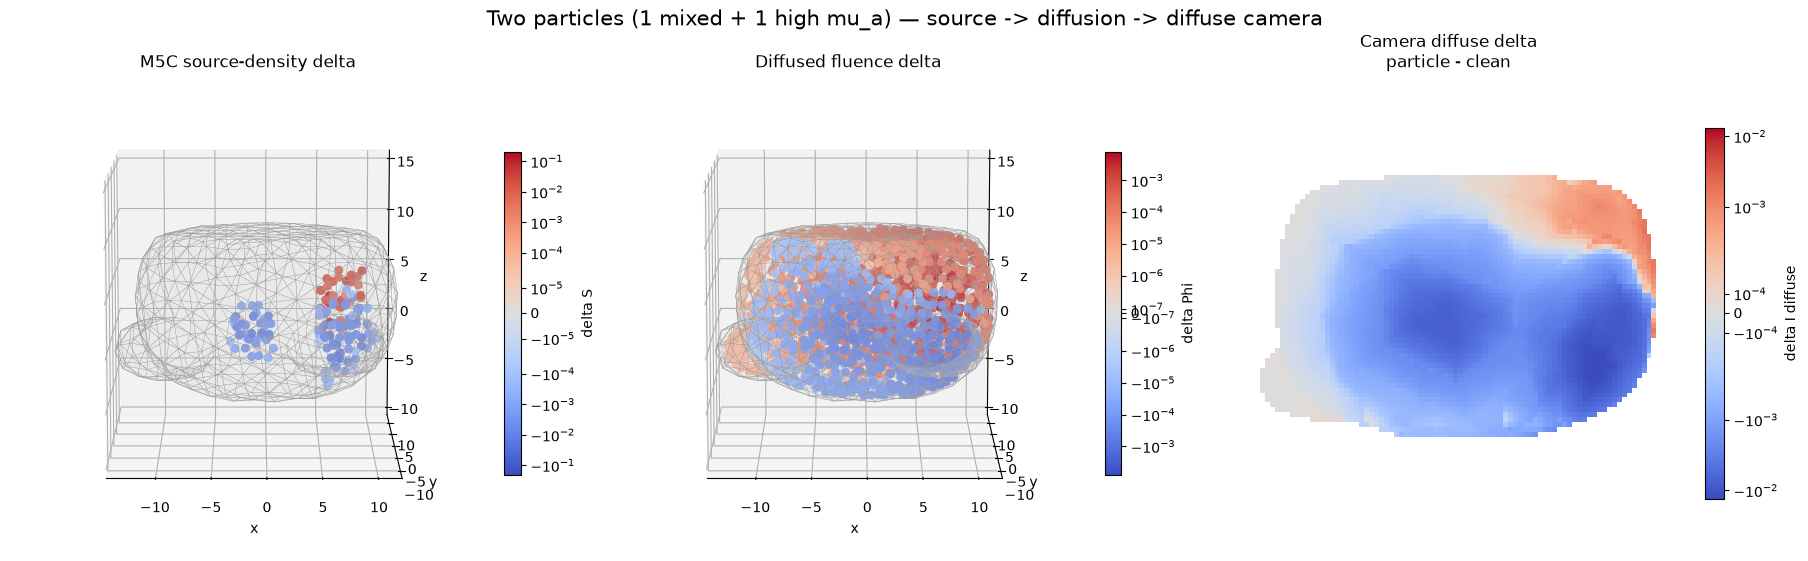

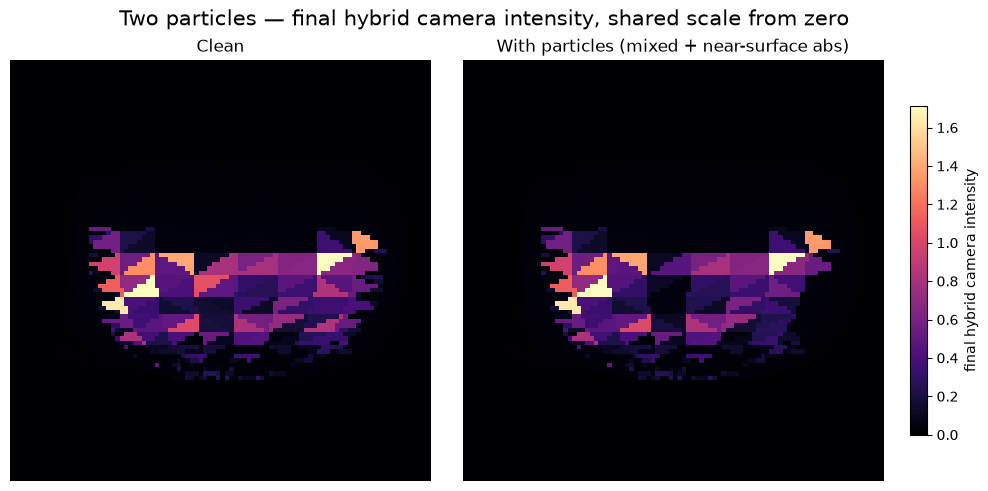

Final camera intensity comparison:
  image type           = final hybrid camera intensity
  clean sum            = 827.8177831896736
  particle sum         = 726.6847779027358
  particle - clean sum = -101.13300528693766


In [9]:
plot_m5d_propagation(
    result_two,
    "Two particles (1 mixed + 1 high mu_a) — source -> diffusion -> diffuse camera",
)

plot_m5d_final_images(
    result_two,
    "Two particles — final hybrid camera intensity, shared scale from zero",
    "With particles (mixed + near-surface abs)",
)


### Interpretation of the two-particle case

- Left: source-density perturbation (1 essentially absorptive, 1 scattering + absorptive).
- Middle: fluence perturbation after diffusion.
- Right: camera-space perturbation (particle − clean).

Causal chain: local source modification → diffuse image-space anomaly.
